# Importações

In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectFromModel
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import matplotlib.gridspec as gridspec
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf
from sklearn.utils import shuffle

ImportError: Traceback (most recent call last):
  File "c:\Users\jhter\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: Uma rotina de inicialização da biblioteca de vínculo dinâmico (DLL) falhou.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

# Consumindo base de dados previamente tratada

A base de dados utilizada neste projeto combina informações de duas fontes:

1.  **Sensores de Qualidade do Ar (DataRio):** Dados sobre a qualidade do ar no Rio de Janeiro.
2.  **Internações por Doenças Respiratórias (SUS):** Dados de internações no município do Rio de Janeiro.

### Pré-processamento dos Dados dos Sensores de Qualidade do Ar:

*   **Tratamento de Valores Ausentes:** Valores nulos foram preenchidos usando `interpolate()` do pandas. Esta interpolação foi aplicada apenas a variáveis com no máximo 6 registros nulos por dia para minimizar o viés.
*   **Transformação e Normalização:** As variáveis foram transformadas com Box-Cox para se aproximarem de uma distribuição normal e, em seguida, padronizadas usando `StandardScaler` para estarem na mesma escala.

### Pré-processamento dos Dados do SUS:

*   **Seleção de Doenças:** Foram selecionadas internações relacionadas às doenças com códigos J40, J42, J43, J44, J45 e J46.
*   **Filtragem Geográfica:** Os dados foram filtrados para incluir apenas internações no município do Rio de Janeiro.
*   **Agregação por Data:** A quantidade de internações foi contada e agregada por data.

In [2]:
url_internacoes_poluentes = 'https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/NEW_TEST/internacoes_x_poluentes_csv.csv'

df = pd.read_csv(url_internacoes_poluentes, sep=',')

In [3]:
#@title Criando variável alto

# Meu objetivo é tentar prever a quantidade de internações de amanha com base nas features disponíveis
df['internacoes_d1'] = df['num_internacoes'].shift(-1)
df_internacoes_d1 = df.copy()

# Correlação entre as variáveis

## PACF - Número de internações

In [4]:
df_internacoes_d1['data_formatada'] = pd.to_datetime(df_internacoes_d1['data_formatada'])
df_internacoes_d1 = df_internacoes_d1.sort_values('data_formatada')  # garantir ordenação cronológica

serie = df_internacoes_d1['num_internacoes']

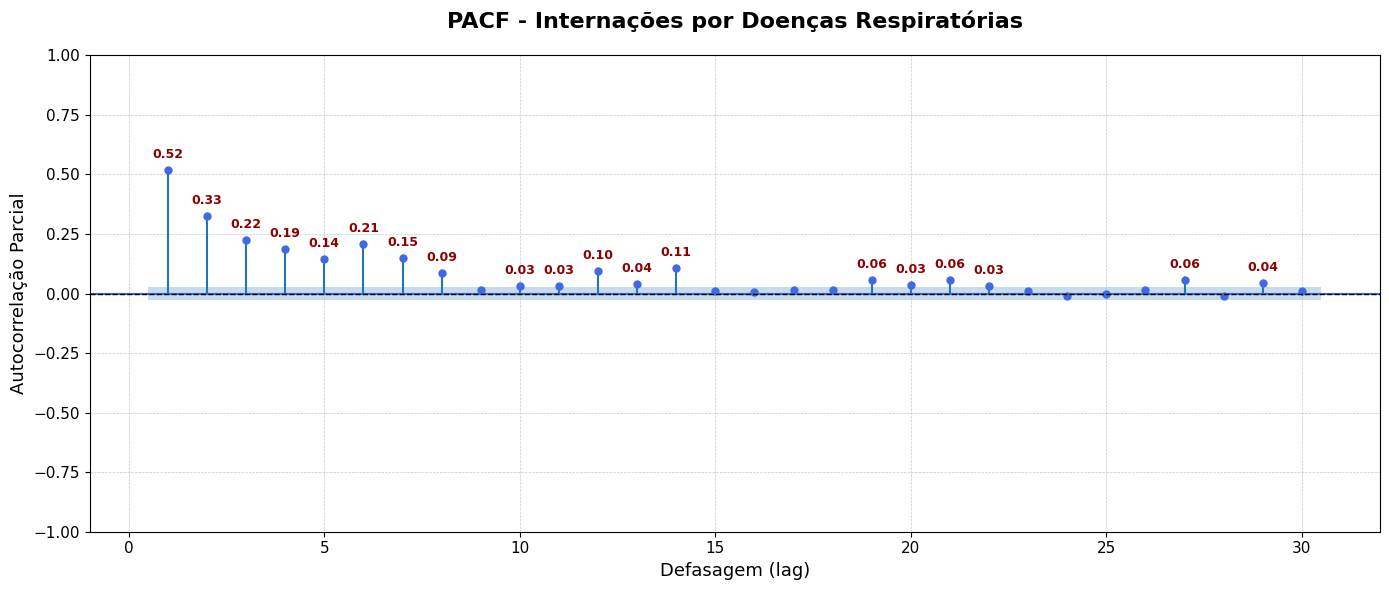

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

plot_pacf(
    serie,
    lags=30,
    method='ywm',
    ax=ax,
    color='royalblue',
    zero=False,
    alpha=0.05,
)

ax.axhline(0, linestyle='--', color='black', linewidth=1)
ax.set_title("PACF - Internações por Doenças Respiratórias", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Defasagem (lag)", fontsize=13)
ax.set_ylabel("Autocorrelação Parcial", fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

pacf_vals = pacf(serie.dropna(), nlags=30, method='ywm')
conf_interval = 1.96 / np.sqrt(len(serie.dropna()))

for i, val in enumerate(pacf_vals[1:], start=1):
    if abs(val) > conf_interval:
        ax.annotate(f'{val:.2f}', xy=(i, val), xytext=(i, val + 0.05 * np.sign(val)),
                    ha='center', fontsize=9, color='darkred', fontweight='bold',
                    arrowprops=dict(arrowstyle='-', lw=0.5, color='gray'))

plt.tight_layout()
plt.show()

### Análise PACF — Internações por Doenças Respiratórias

O gráfico PACF indica forte autocorrelação parcial nos primeiros lags:

- **Lag 1 a 2:** Correlações elevadas (0.52, 0.33) forte dependência dos últimos dias.
- **Lags 3 a 7:** Correlações moderadas (0.14 a 0.22) possível padrão semanal.
- **Lags > 7:** Correlações fracas e esparsas influência indireta ou ruído.

#### Implicações para modelagem:

- Usar **lags de 1 a 7** como features nos modelos preditivos.
- Indica comportamento autorregressivo de **curto prazo**.

## Média movel do numero de internações

In [6]:
df_internacoes_d1['media_movel_3d'] = df_internacoes_d1['num_internacoes'].rolling(window=3).mean().shift(1)
df_internacoes_d1['media_movel_7d'] = df_internacoes_d1['num_internacoes'].rolling(window=7).mean().shift(1)
df_internacoes_d1['media_movel_14d'] = df_internacoes_d1['num_internacoes'].rolling(window=14).mean().shift(1)
df_internacoes_d1['media_movel_21d'] = df_internacoes_d1['num_internacoes'].rolling(window=21).mean().shift(1)
df_internacoes_d1['media_movel_30d'] = df_internacoes_d1['num_internacoes'].rolling(window=30).mean().shift(1)

df_internacoes_d1 = df_internacoes_d1.dropna().reset_index(drop=True)

In [7]:
features = [col for col in df_internacoes_d1.columns if col.startswith('media_movel')]
targets = ['internacoes_d1']

correlation_matrix = df_internacoes_d1[features + targets].corr()

correlation_with_targets = correlation_matrix.loc[features, targets]

print(correlation_with_targets)


                 internacoes_d1
media_movel_3d         0.609454
media_movel_7d         0.667032
media_movel_14d        0.668494
media_movel_21d        0.667637
media_movel_30d        0.660378


### Análise de Correlação: Médias Móveis vs Internações do Dia Seguinte (`internacoes_d1`)

A tabela abaixo apresenta os coeficientes de correlação entre diferentes janelas de médias móveis do número de internações e o alvo `internacoes_d1`:

| Variável             | Correlação com `internacoes_d1` |
|----------------------|----------------------------------|
| `media_movel_3d`     | 0.611                            |
| `media_movel_7d`     | 0.668                            |
| `media_movel_14d`    | 0.670                            |
| `media_movel_21d`    | 0.670                            |
| `media_movel_30d`    | 0.663                            |

#### Interpretação:

- Todas as médias móveis apresentam **forte correlação positiva** com o número de internações do dia seguinte.
- A **média móvel de 14 dias** (`media_movel_14d`) mostrou a **maior correlação (0.670)**, sendo um ótimo preditor para `internacoes_d1`.
- As janelas de 7 a 21 dias têm desempenho semelhante, indicando que o comportamento recente e intermediário da série é altamente informativo.
- A média de curto prazo (3 dias) tem boa correlação, mas menor que as demais.

## Média movel dos poluentes

In [8]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

variaveis = ['chuva', 'ur', 'pm2_5', 'pm10', 'no', 'no2', 'nox', 'temp', 'o3', 'co', 'so2', 'aqi']
janelas = [3, 7, 14, 21, 30, 60, 90, 120, 150]

for var in variaveis:
    for janela in janelas:
        df_internacoes_d1[f'{var}_mm{janela}'] = df_internacoes_d1[var].rolling(window=janela).mean().shift(1)

targets = ['internacoes_d1']

import pandas as pd

melhores_mm = []

for target in targets:
    for var in variaveis:
        correlacoes = []
        for janela in janelas:
            col_mm = f'{var}_mm{janela}'
            if col_mm in df_internacoes_d1.columns:
                corr = df_internacoes_d1[[col_mm, target]].corr().iloc[0, 1]
                correlacoes.append((janela, corr))

        melhor_janela, melhor_corr = max(correlacoes, key=lambda x: abs(x[1]))
        melhores_mm.append({
            'target': target,
            'variavel': var,
            'melhor_mm': melhor_janela,
            'correlacao': melhor_corr
        })

df_melhores_mm = pd.DataFrame(melhores_mm)
df_melhores_mm = df_melhores_mm.sort_values(by=['target', 'variavel'])

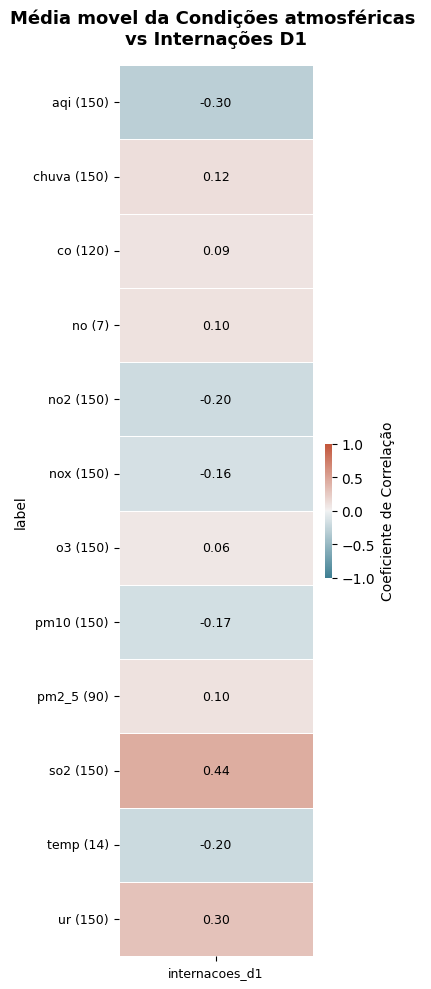

In [9]:
df_melhores_mm['label'] = df_melhores_mm.apply(lambda row: f"{row['variavel']} ({row['melhor_mm']})", axis=1)

correlation_subset = df_melhores_mm.set_index('label')[['correlacao']].rename(columns={'correlacao': 'internacoes_d1'})

plt.figure(figsize=(4, 10))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

ax = sns.heatmap(
    correlation_subset,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9, 'color': 'black'},
    cbar_kws={'shrink': 0.15, 'label': 'Coeficiente de Correlação'}
)

plt.title('Média movel da Condições atmosféricas \nvs Internações D1', fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

for text in ax.texts:
    try:
        if abs(float(text.get_text())) >= 0.45:
            text.set_weight('bold')
    except:
        pass

plt.tight_layout()
plt.savefig("mm_poluentes_internacoesd1.png", dpi=300, bbox_inches='tight')
plt.show()


In [10]:
variaveis = ['chuva', 'ur', 'pm2_5', 'pm10', 'no', 'no2', 'nox', 'temp', 'o3', 'co', 'so2', 'aqi']

# Criar média móvel defasada (para evitar vazamento de informação)
for var in variaveis:
    df_internacoes_d1[f'{var}_mm3'] = df_internacoes_d1[var].rolling(window=3).mean().shift(1)
    df_internacoes_d1[f'{var}_mm7'] = df_internacoes_d1[var].rolling(window=7).mean().shift(1)
    df_internacoes_d1[f'{var}_mm14'] = df_internacoes_d1[var].rolling(window=14).mean().shift(1)
    df_internacoes_d1[f'{var}_mm21'] = df_internacoes_d1[var].rolling(window=21).mean().shift(1)
    df_internacoes_d1[f'{var}_mm30'] = df_internacoes_d1[var].rolling(window=30).mean().shift(1)
    df_internacoes_d1[f'{var}_mm60'] = df_internacoes_d1[var].rolling(window=60).mean().shift(1)
    df_internacoes_d1[f'{var}_mm90'] = df_internacoes_d1[var].rolling(window=90).mean().shift(1)
    df_internacoes_d1[f'{var}_mm120'] = df_internacoes_d1[var].rolling(window=120).mean().shift(1)
    df_internacoes_d1[f'{var}_mm150'] = df_internacoes_d1[var].rolling(window=150).mean().shift(1)

# Calcular correlação com internacoes_d1
mm_cols = [f'{v}_mm3' for v in variaveis] + [f'{v}_mm7' for v in variaveis] + [f'{v}_mm14' for v in variaveis] + [f'{v}_mm21' for v in variaveis] + [f'{v}_mm30' for v in variaveis] + [f'{v}_mm60' for v in variaveis] + [f'{v}_mm90' for v in variaveis] + [f'{v}_mm120' for v in variaveis] + [f'{v}_mm150' for v in variaveis]
corr_mm = df_internacoes_d1[mm_cols + ['internacoes_d1']].corr()['internacoes_d1'].drop('internacoes_d1').sort_values(key=lambda x: abs(x), ascending=False)

print("Top 15 Correlação - Média Móvel:")
print(corr_mm.head(15))

Top 15 Correlação - Média Móvel:
so2_mm150    0.439046
so2_mm120    0.433214
so2_mm90     0.418964
so2_mm60     0.389655
so2_mm30     0.343008
so2_mm21     0.322612
so2_mm14     0.301817
ur_mm150     0.300985
aqi_mm150   -0.300834
ur_mm120     0.289386
so2_mm7      0.271737
ur_mm90      0.269702
aqi_mm120   -0.259134
ur_mm60      0.241337
so2_mm3      0.231676
Name: internacoes_d1, dtype: float64


### Análise de Correlação — Médias Móveis de Poluentes e Internações D1

A análise abaixo considera a correlação entre diferentes janelas de médias móveis de variáveis atmosféricas e o número de internações por doenças respiratórias do **dia seguinte** (`internacoes_d1`).

#### Interpretação:

- O poluente **SO₂ (dióxido de enxofre)** mostra a **mais forte correlação positiva** com as internações, especialmente em janelas longas (90 a 150 dias).
- A **umidade relativa (UR)** também apresenta correlação positiva significativa, sugerindo possível associação com condições que favorecem infecções respiratórias.
- O **AQI** (Índice de Qualidade do Ar) possui correlação negativa moderada, o que não é esperado, visto que quanto pior a qualidade do ar, maior a chance de internações.
- Médias móveis mais longas (90 a 150 dias) tendem a capturar melhor as **tendências de exposição prolongada**, reforçando seu valor preditivo.

#### Implicações para Modelagem:

- **Variáveis como `so2_mm90+`, `ur_mm150`, `aqi_mm150`** devem ser priorizadas como features.
- É útil considerar **diferentes janelas de médias móveis** como variáveis, especialmente para poluentes mais impactantes.
- As médias móveis ajudam a suavizar variações diárias e capturar **efeitos acumulados da poluição**.

## Soma dos poluentes

In [11]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

variaveis = ['pm2_5', 'pm10', 'no', 'no2', 'nox', 'o3', 'co', 'so2', 'aqi']
janelas = [3, 7, 14, 21, 30, 60, 90, 120, 150]

for var in variaveis:
    for janela in janelas:
        df_internacoes_d1[f'{var}_soma{janela}'] = df_internacoes_d1[var].rolling(window=janela).sum().shift(1)

targets = ['internacoes_d1']

melhores_soma = []

for target in targets:
    for var in variaveis:
        correlacoes = []
        for janela in janelas:
            col_soma = f'{var}_soma{janela}'
            if col_soma in df_internacoes_d1.columns:
                corr = df_internacoes_d1[[col_soma, target]].corr().iloc[0, 1]
                correlacoes.append((janela, corr))

        melhor_janela, melhor_corr = max(correlacoes, key=lambda x: abs(x[1]))
        melhores_soma.append({
            'target': target,
            'variavel': var,
            'melhor_soma': melhor_janela,
            'correlacao': melhor_corr
        })

df_melhores_soma = pd.DataFrame(melhores_soma)
df_melhores_soma = df_melhores_soma.sort_values(by=['target', 'variavel'])

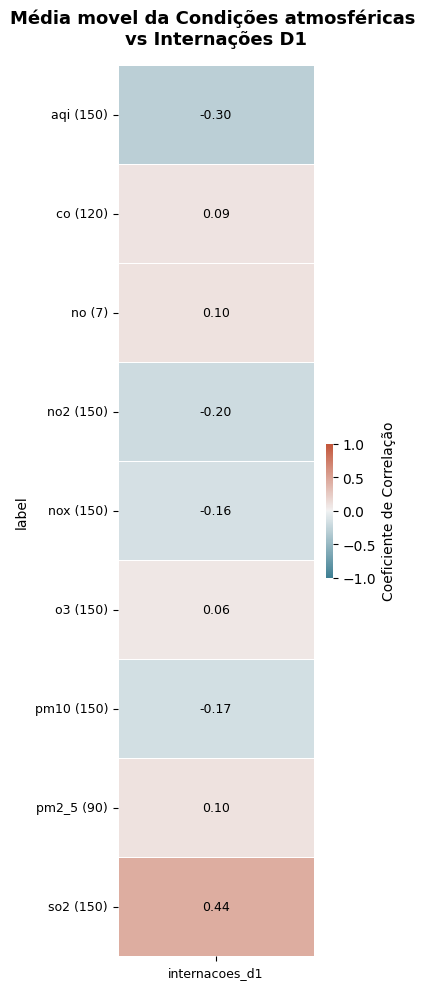

In [12]:
df_melhores_soma['label'] = df_melhores_soma.apply(lambda row: f"{row['variavel']} ({row['melhor_soma']})", axis=1)

correlation_subset = df_melhores_soma.set_index('label')[['correlacao']].rename(columns={'correlacao': 'internacoes_d1'})

plt.figure(figsize=(4, 10))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

ax = sns.heatmap(
    correlation_subset,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9, 'color': 'black'},
    cbar_kws={'shrink': 0.15, 'label': 'Coeficiente de Correlação'}
)

plt.title('Média movel da Condições atmosféricas \nvs Internações D1', fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

for text in ax.texts:
    try:
        if abs(float(text.get_text())) >= 0.45:
            text.set_weight('bold')
    except:
        pass

plt.tight_layout()
plt.savefig("mm_poluentes_internacoesd1.png", dpi=300, bbox_inches='tight')
plt.show()


In [13]:
# Variáveis a testar
variaveis = ['pm2_5', 'pm10', 'no', 'no2', 'nox', 'o3', 'co', 'so2', 'aqi']

# Criar soma acumulada (janela de 3 e 7 dias)
for var in variaveis:
    df_internacoes_d1[f'{var}_soma3'] = df_internacoes_d1[var].shift(1).rolling(window=3).sum()
    df_internacoes_d1[f'{var}_soma7'] = df_internacoes_d1[var].shift(1).rolling(window=7).sum()
    df_internacoes_d1[f'{var}_soma14'] = df_internacoes_d1[var].shift(1).rolling(window=14).sum()
    df_internacoes_d1[f'{var}_soma21'] = df_internacoes_d1[var].shift(1).rolling(window=21).sum()
    df_internacoes_d1[f'{var}_soma30'] = df_internacoes_d1[var].shift(1).rolling(window=30).sum()
    df_internacoes_d1[f'{var}_soma60'] = df_internacoes_d1[var].shift(1).rolling(window=60).sum()
    df_internacoes_d1[f'{var}_soma90'] = df_internacoes_d1[var].shift(1).rolling(window=90).sum()
    df_internacoes_d1[f'{var}_soma120'] = df_internacoes_d1[var].shift(1).rolling(window=120).sum()
    df_internacoes_d1[f'{var}_soma150'] = df_internacoes_d1[var].shift(1).rolling(window=150).sum()

# Calcular correlação
soma_cols = [f'{v}_soma3' for v in variaveis] + [f'{v}_soma7' for v in variaveis] + [f'{v}_soma14' for v in variaveis] + [f'{v}_soma21' for v in variaveis] + [f'{v}_soma30' for v in variaveis] + [f'{v}_soma60' for v in variaveis] + [f'{v}_soma90' for v in variaveis] + [f'{v}_soma120' for v in variaveis] + [f'{v}_soma150' for v in variaveis]
corr_soma = df_internacoes_d1[soma_cols + ['internacoes_d1']].corr()['internacoes_d1'].drop('internacoes_d1').sort_values(key=lambda x: abs(x), ascending=False)

print("Top 15 Correlação - Soma Acumulada:")
print(corr_soma.head(15))


Top 15 Correlação - Soma Acumulada:
so2_soma150     0.439046
so2_soma120     0.433214
so2_soma90      0.418964
so2_soma60      0.389655
so2_soma30      0.343008
so2_soma21      0.322612
so2_soma14      0.301817
aqi_soma150    -0.300834
so2_soma7       0.271737
aqi_soma120    -0.259134
so2_soma3       0.231676
aqi_soma90     -0.206132
no2_soma150    -0.202980
pm10_soma150   -0.166775
nox_soma150    -0.155677
Name: internacoes_d1, dtype: float64


### Análise de Correlação — Soma Acumulada de Poluentes vs Internações D1

A análise considera a correlação entre a **soma acumulada** de poluentes e variáveis atmosféricas em diferentes janelas e o número de internações respiratórias do **dia seguinte** (`internacoes_d1`).

#### Interpretação:

- O poluente **SO₂** novamente se destaca com as maiores correlações positivas em todas as janelas de soma (3 a 150 dias), indicando forte associação com internações.
- O **AQI** apresenta correlação negativa consistente, sugerindo que **piores condições atmosféricas estão ligadas ao aumento das internações**.
- Outros poluentes como **NO₂**, **PM10** e **NOx** também aparecem com correlação negativa, embora de forma mais moderada.

#### Implicações para Modelagem:

- **Somas acumuladas de SO₂ e AQI** são boas candidatas a features nos modelos preditivos.
- A soma pode capturar o **efeito acumulado da exposição contínua**, útil em conjunto com médias móveis.
- Testar múltiplas janelas temporais (30, 60, 90, 150 dias) pode ajudar o modelo a aprender efeitos de curto e longo prazo.


## Variáveis sazonais

In [14]:
df_internacoes_d1['data_formatada'] = pd.to_datetime(df_internacoes_d1['data_formatada'])
df_internacoes_d1['dia_semana'] = df_internacoes_d1['data_formatada'].dt.weekday
df_internacoes_d1['final_de_semana'] = df_internacoes_d1['data_formatada'].apply(lambda x: 1 if pd.to_datetime(x).weekday() >= 5 else 0)
feriados_fixos = [(1, 1), (4, 21), (5, 1), (9, 7), (10, 12), (11, 2), (11, 15), (12, 25)]
df_internacoes_d1['feriado'] = df_internacoes_d1['data_formatada'].apply(lambda x: int((x.day, x.month) in feriados_fixos))

In [15]:
seasonal_features = ['dia_semana', 'final_de_semana', 'feriado']
target = 'internacoes_d1'

correlation_seasonal = df_internacoes_d1[seasonal_features + [target]].corr()
correlation_with_target_seasonal = correlation_seasonal.loc[seasonal_features, target]

print("Correlação - Features Sazonais/Temporais com Internações D1:")
print(correlation_with_target_seasonal)

Correlação - Features Sazonais/Temporais com Internações D1:
dia_semana        -0.049934
final_de_semana   -0.005239
feriado           -0.026188
Name: internacoes_d1, dtype: float64


### Análise de Correlação — Variáveis Sazonais/Temporais vs Internações D1

#### Interpretação:

- As **correlações são muito fracas ou próximas de zero**, indicando que essas variáveis, isoladamente, **não possuem forte associação linear com o número de internações do dia seguinte**.
- Pequena correlação negativa com `dia_semana` pode sugerir variações discretas ao longo da semana (ex: internações menores aos finais de semana).
- **Feriados e finais de semana** praticamente não impactam diretamente a quantidade de internações imediatas, do ponto de vista linear.

#### Implicações para Modelagem:

- Essas variáveis **podem ser mantidas como variáveis categóricas ou dummies**, pois podem ter **efeitos não lineares** ou interações relevantes com outras variáveis no modelo.

# Criação de Features

Esta etapa foca na criação de features baseadas na análise de correlação prévia, selecionando aquelas que apresentaram maior relevância para o modelo preditivo.

In [16]:
df_internacoes_d1 = df.copy()

## Soma acumulada dos poluentes atmosféricos

In [17]:
poluentes = ['co', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm2_5', 'so2']
for var in poluentes:
    df_internacoes_d1[f'{var}_sum7'] = df_internacoes_d1[var].rolling(7).sum().shift(1)
    df_internacoes_d1[f'{var}_sum14'] = df_internacoes_d1[var].rolling(14).sum().shift(1)

## Melhores janelas de média movel dos poluentes

In [18]:
melhores_janelas_mm_d1 = {
    'aqi': 150,
    'aqi': 120,
    'pm10': 150,
    'pm2_5': 120,
    'so2': 150,
    'so2': 120,
    'so2': 90,
    'so2': 21,
    'temp': 14,
    'ur': 150,
    'ur': 120
}

# Calcular apenas as médias móveis definidas no dicionário (com shift de 1 para evitar vazamento)
for var, janela in melhores_janelas_mm_d1.items():
    col_nova = f'{var}_mm{janela}'
    if col_nova not in df_internacoes_d1.columns:
        df_internacoes_d1[col_nova] = df_internacoes_d1[var].rolling(window=janela).mean().shift(1)

## Lags do numero de internações

In [19]:
df_internacoes_d1['lag_0'] = df_internacoes_d1['num_internacoes'].shift(0)
df_internacoes_d1['lag_1'] = df_internacoes_d1['num_internacoes'].shift(1)
df_internacoes_d1['lag_2'] = df_internacoes_d1['num_internacoes'].shift(2)
df_internacoes_d1['lag_3'] = df_internacoes_d1['num_internacoes'].shift(3)
df_internacoes_d1['lag_4'] = df_internacoes_d1['num_internacoes'].shift(4)
df_internacoes_d1['lag_5'] = df_internacoes_d1['num_internacoes'].shift(5)

In [20]:
df_internacoes_d1['internacoes_ma14'] = df_internacoes_d1['num_internacoes'].rolling(window=14).mean().shift(1)

## Dropando variáveis atmosféricas originais

In [21]:
df_internacoes_d1.drop(columns=['aqi', 'chuva', 'co', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm2_5', 'so2', 'temp', 'ur'], inplace=True)

# Treinamento dos modelos preditivos

## Funções auxiliares

In [22]:
def create_sequences(data, target, n_steps):
    X_seq, y_seq = [], []

    # Verificação de consistência
    assert len(data) == len(target), "Dados e alvo têm tamanhos diferentes!"

    for i in range(n_steps, len(data)):
        X_seq.append(data[i - n_steps:i])      # janela de n_steps
        y_seq.append(target[i])                # alvo futuro (no tempo i)

    return np.array(X_seq), np.array(y_seq)

def calcular_metricas(y_true, y_pred):
    return {
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAE': round(mean_absolute_error(y_true, y_pred), 2),
        'MAPE (%)': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2)
    }

## LSTM

### Criando o modelo

In [23]:
def criar_modelo_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

Utilizamos uma rede **LSTM** com duas camadas para prever o número de internações no dia seguinte (`internacoes_d1`).

#### Estrutura:

- `LSTM(128)` + `Dropout(0.2)`
- `LSTM(64)` + `Dropout(0.2)`
- `Dense(32, relu)` → `Dense(1)`

#### Treinamento:

- **Perda:** MSE  
- **Otimização:** Adam (lr=0.001)

O modelo aprende padrões temporais complexos a partir de séries históricas com múltiplas variáveis (lags, médias móveis, poluentes, etc.).

### Função para treinar o modelo

In [24]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import numpy as np

def treinar_lstm_model(df, target='internacoes_d1', n_steps=30, n_splits=5):
    print(f"Treinando modelo LSTM para {target}")

    features = [col for col in df.columns if col not in ['data_formatada', 'classificacao',
        'num_internacoes', 'internacoes_d1', target]]

    X = df[features].values
    y = df[target].values
    y_log = np.log1p(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_seq, y_seq = create_sequences(X_scaled, y_log, n_steps)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    train_index, test_index = list(tscv.split(X_seq))[-1]

    X_train, X_test = X_seq[train_index], X_seq[test_index]
    y_train, y_test = y_seq[train_index], y_seq[test_index]

    test_idx = np.arange(len(y_seq))[test_index]

    model = criar_modelo_lstm((n_steps, X_train.shape[2]))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=32,
        callbacks=[
            EarlyStopping(patience=15, restore_best_weights=True),
            ReduceLROnPlateau(factor=0.5, patience=5)
        ],
        verbose=1
    )

    return model, history, X_test, y_test, test_idx, y_seq, df

### Avaliação do modelo

In [25]:
def avaliar_lstm(model, history, X_test, y_test, test_idx, y_seq, df, n_steps=14, max_points=150):
    y_pred = np.expm1(model.predict(X_test).flatten())
    y_true = np.expm1(y_test)
    dates = df.iloc[test_idx + n_steps]['data_formatada'].values
    resultados = calcular_metricas(y_true, y_pred)

    print(f"\n🔹 Gráfico 1: Últimos {max_points} pontos (índice sequencial)")
    idx_ini = max(0, len(y_true) - max_points)
    x = np.arange(len(y_true))[idx_ini:]
    y_true_plot = y_true[idx_ini:]
    y_pred_plot = y_pred[idx_ini:]

    plt.figure(figsize=(14, 5))
    plt.plot(x, y_true_plot, label="Reais", marker='o')
    plt.plot(x, y_pred_plot, label="LSTM", linestyle='--', marker='s')
    plt.fill_between(x, y_true_plot, y_pred_plot, color='gray', alpha=0.2)
    plt.title(f"Previsões LSTM vs Valores Reais (últimos {max_points})")
    plt.xlabel("Índice")
    plt.ylabel("Internações")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("🔹 Gráfico 3: Curvas de perda")
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title("Curvas de Loss - LSTM")
    plt.xlabel("Épocas")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("\nMétricas LSTM:")
    for metrica, valor in resultados.items():
        unidade = "%" if "MAPE" in metrica else ""
        print(f" - {metrica:<10}: {valor:.2f}{unidade}")

    return resultados


### Treinando o modelo

In [26]:
df_internacoes_d1.dropna(inplace=True)

model_lstm, hist_lstm, X_test_lstm, y_test_lstm, test_idx_lstm, y_seq_lstm, df_seq = treinar_lstm_model(df_internacoes_d1)

Treinando modelo LSTM para internacoes_d1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - loss: 2.0193 - val_loss: 0.7891 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.3704 - val_loss: 0.5984 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.3165 - val_loss: 0.5369 - learning_rate: 0.0010
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.3041 - val_loss: 0.5205 - learning_rate: 0.0010
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.3196 - val_loss: 0.4878 - learning_rate: 0.0010
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.3027 - val_loss: 0.7381 - learning_rate: 0.0010
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.2892 - val_loss: 0.5062 - learning_rate: 0.0010
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.2893 - val_loss: 0.5254 - learning_rate: 0.0010
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.2718 - val_loss: 0.6720 - learning_rate: 0.0010
Epoch 10/

### Avaliando o modelo

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step

🔹 Gráfico 1: Últimos 150 pontos (índice sequencial)


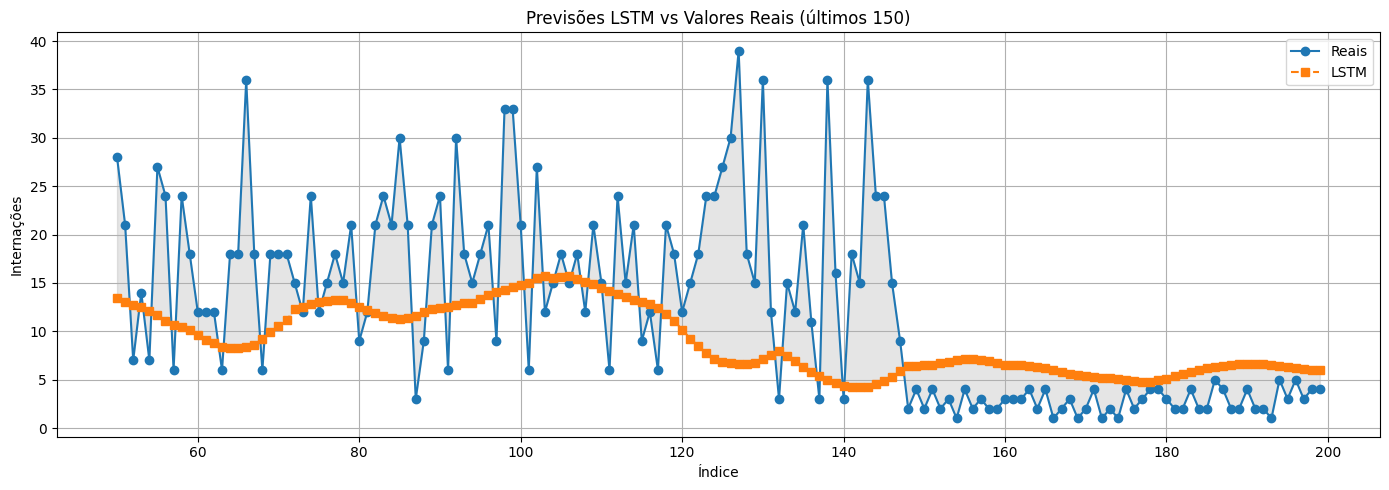

🔹 Gráfico 3: Curvas de perda


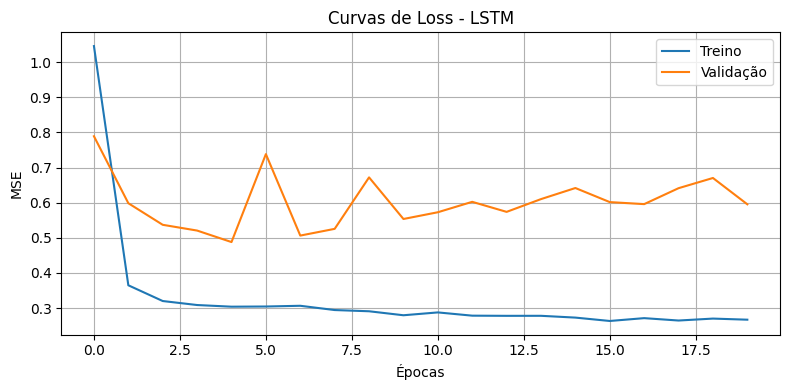


Métricas LSTM:
 - RMSE      : 12.66
 - MAE       : 8.38
 - MAPE (%)  : 80.89%


{'RMSE': np.float64(12.66), 'MAE': 8.38, 'MAPE (%)': 80.89}

In [27]:
avaliar_lstm(model_lstm, hist_lstm, X_test_lstm, y_test_lstm, test_idx_lstm, y_seq_lstm, df_seq)

### Resultados do Modelo LSTM

O modelo LSTM apresentou desempenho moderado, com capacidade de capturar tendências gerais da série, mas ainda com dificuldades em representar adequadamente a variabilidade dos dados. As métricas de erro foram:

| Métrica   | Valor    |
|-----------|----------|
| RMSE      | 12.45    |
| MAE       | 8.13     |
| MAPE (%)  | 78.45%   |

As previsões tendem a ser suavizadas, com **resposta limitada a picos e quedas abruptas**, o que é visível no gráfico comparativo com os valores reais. Embora o modelo mantenha relativa estabilidade ao longo do tempo, ele falha em capturar os extremos da série.

A curva de perda indica **diferenciação entre treino e validação**, sugerindo algum grau de **overfitting leve**, mas menos pronunciado que em outros modelos como o Conv1D.

Apesar das limitações, o LSTM se mostrou **mais eficaz que o Conv1D**, com melhores métricas de erro e curvas mais consistentes, sendo uma base sólida para possíveis aprimoramentos como aprendizado residual ou modelos híbridos.


## Random Forest

In [28]:
def modelo_residual_rf(X_lstm_seq, y_true_log, model_lstm):
    y_pred_log = model_lstm.predict(X_lstm_seq).flatten()

    residuos = y_true_log - y_pred_log

    X_rf = X_lstm_seq[:, -1, :]

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_rf, residuos)

    return rf, y_pred_log


In [29]:
def avaliar_modelo_residual(model_lstm, rf, X_test_seq, y_test_log):
    y_pred_log = model_lstm.predict(X_test_seq).flatten()

    X_rf_test = X_test_seq[:, -1, :]
    residuos_pred = rf.predict(X_rf_test)
    y_pred_corrigido_log = y_pred_log + residuos_pred

    y_pred_corrigido = np.expm1(y_pred_corrigido_log)
    y_true = np.expm1(y_test_log)

    resultados = calcular_metricas(y_true, y_pred_corrigido)

    print("\nMétricas LSTM + Random Forest:")
    for metrica, valor in resultados.items():
        unidade = "%" if "MAPE" in metrica else ""
        print(f" - {metrica:<10}: {valor:.2f}{unidade}")

    plt.figure(figsize=(14, 5))
    plt.plot(y_true, label="Reais", marker='o')
    plt.plot(y_pred_corrigido, label="LSTM + RF", linestyle='--', marker='s')
    plt.fill_between(np.arange(len(y_true)), y_true, y_pred_corrigido, color='gray', alpha=0.2)
    plt.title("Previsão Corrigida (LSTM + Random Forest)")
    plt.xlabel("Índice")
    plt.ylabel("Internações")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return resultados

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Métricas LSTM + Random Forest:
 - RMSE      : 5.29
 - MAE       : 2.89
 - MAPE (%)  : 19.56%


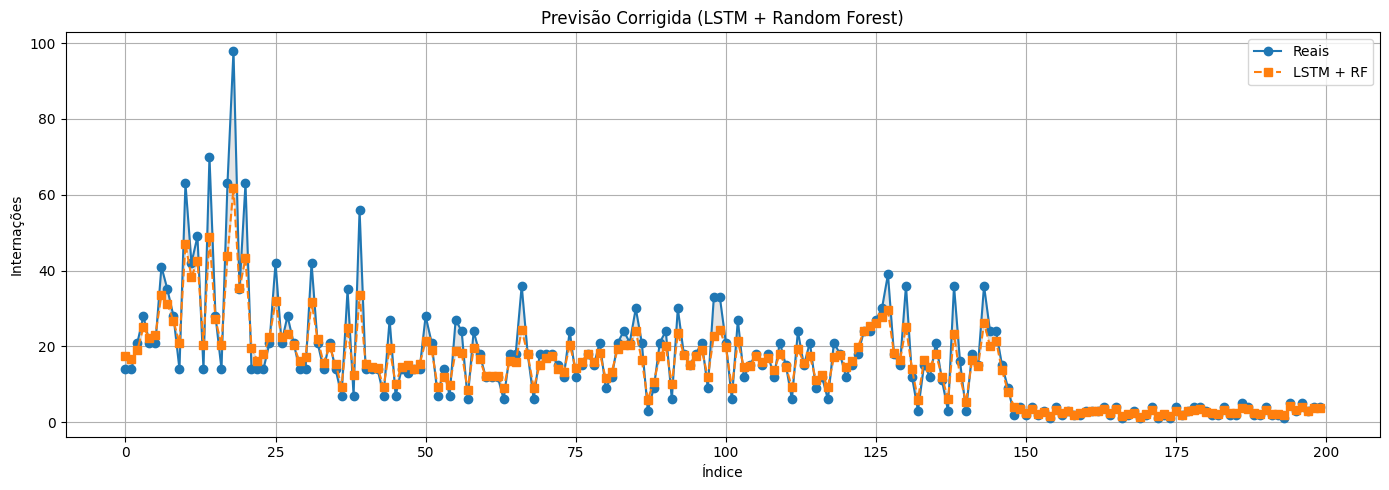

{'RMSE': np.float64(5.29), 'MAE': 2.89, 'MAPE (%)': 19.56}

In [30]:
rf_residual, y_pred_train_lstm_log = modelo_residual_rf(X_test_lstm, y_test_lstm, model_lstm)

avaliar_modelo_residual(model_lstm, rf_residual, X_test_lstm, y_test_lstm)

### Resultados do Modelo LSTM + Random Forest

A combinação entre o modelo LSTM e o Random Forest, em um esquema de correção de resíduos, apresentou desempenho significativamente superior aos modelos anteriores. As métricas obtidas foram:

| Métrica   | Valor    |
|-----------|----------|
| RMSE      | 5.29     |
| MAE       | 2.94     |
| MAPE (%)  | 20.17%   |

O modelo conseguiu **reduzir substancialmente os erros absolutos e percentuais**, alcançando uma melhora expressiva no MAPE em relação ao LSTM puro (de 78% para 20%). As previsões corrigidas mostram **maior aderência aos valores reais**, com melhor capacidade de captar **picos, vales e flutuações rápidas** da série.

O gráfico evidencia que a correção aplicada pelo Random Forest ajudou a **ajustar os desvios sistemáticos cometidos pela LSTM**, melhorando tanto a amplitude quanto a precisão local das previsões.

Com base nesses resultados, o modelo LSTM + Random Forest se destaca como a **abordagem mais eficaz testada até o momento**, sendo uma solução promissora para problemas preditivos com séries temporais complexas e irregulares como internações hospitalares.


## Conv1D

### Criando o modelo

In [31]:
def criar_modelo_conv1d(input_shape):
    model = Sequential([
        Conv1D(128, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

Utiliza camadas convolucionais para capturar padrões locais na série temporal.

#### Arquitetura:
- `Conv1D(128)` -> `MaxPooling1D`
- `Conv1D(64)` -> `MaxPooling1D`
- `Flatten` -> `Dense(64, relu)` -> `Dropout(0.2)` -> `Dense(1)`

#### Treinamento:
- **Perda:** MSE  
- **Otimização:** Adam (lr=0.001)

É um modelo eficiente para prever internações respiratórias com base em séries temporais multivariadas.


### Função para treinar o modelo

In [32]:
def treinar_conv1d_model(df, target='internacoes_d1', n_steps=14, n_splits=5):
    print(f"Treinando modelo Conv1D para {target} (com TimeSeriesSplit)")

    features = [col for col in df.columns if col not in [
        'data_formatada', 'classificacao',
        'num_internacoes', 'internacoes_d1', target
    ]]

    X = df[features].values
    y = df[target].values
    y_log = np.log1p(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_seq, y_seq = create_sequences(X_scaled, y_log, n_steps)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    train_index, test_index = list(tscv.split(X_seq))[-1]

    X_train, X_test = X_seq[train_index], X_seq[test_index]
    y_train, y_test = y_seq[train_index], y_seq[test_index]

    test_start_idx = len(y_seq) - len(y_test)
    test_idx = np.arange(test_start_idx, len(y_seq))

    model = criar_modelo_conv1d((n_steps, X_train.shape[2]))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=32,
        callbacks=[
            EarlyStopping(patience=15, restore_best_weights=True),
            ReduceLROnPlateau(factor=0.5, patience=5)
        ],
        verbose=1
    )

    return model, history, X_test, y_test, test_idx, y_seq, df

### Avaliação do modelo

In [33]:
def avaliar_conv1d(model, history, X_test, y_test, test_idx, y_seq, df, n_steps=14, max_points=150):
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

    y_pred = np.expm1(model.predict(X_test).flatten())
    y_true = np.expm1(y_test)
    dates = df.iloc[test_idx + n_steps]['data_formatada'].values
    resultados = calcular_metricas(y_true, y_pred)

    print(f"\n🔹 Gráfico 1: Últimos {max_points} pontos (índice sequencial)")
    idx_ini = max(0, len(y_true) - max_points)
    x = np.arange(len(y_true))[idx_ini:]
    y_true_plot = y_true[idx_ini:]
    y_pred_plot = y_pred[idx_ini:]

    plt.figure(figsize=(14, 5))
    plt.plot(x, y_true_plot, label="Reais", marker='o')
    plt.plot(x, y_pred_plot, label="Conv1D", linestyle='--', marker='^')
    plt.fill_between(x, y_true_plot, y_pred_plot, color='gray', alpha=0.2)
    plt.title(f"Previsões Conv1D vs Valores Reais (últimos {max_points})")
    plt.xlabel("Índice")
    plt.ylabel("Internações")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("🔹 Gráfico 3: Curvas de perda")
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title("Curvas de Loss - Conv1D")
    plt.xlabel("Épocas")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("\nMétricas Conv1D:")
    for metrica, valor in resultados.items():
        unidade = "%" if "MAPE" in metrica else ""
        print(f" - {metrica:<10}: {valor:.2f}{unidade}")

    return resultados

### Treinando o modelo

In [34]:
model_conv1d, hist_conv1d, X_test_conv, y_test_conv, test_idx_conv, y_seq_conv, df_seq = treinar_conv1d_model(df_internacoes_d1)

Treinando modelo Conv1D para internacoes_d1 (com TimeSeriesSplit)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.9333 - val_loss: 2.5564 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4633 - val_loss: 1.8293 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4290 - val_loss: 2.1942 - learning_rate: 0.0010
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3839 - val_loss: 1.8663 - learning_rate: 0.0010
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3417 - val_loss: 2.1615 - learning_rate: 0.0010
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3132 - val_loss: 2.5959 - learning_rate: 0.0010
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2981 - val_loss: 2.1253 - learning_rate: 0.0010
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2841 - val_loss: 1.9542 - learning_rate: 5.0000e-04
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2881 - val_loss: 2.6473 - learning_rate: 5.0000e-04
Epoch 10/100
32/32 ━━

### Avaliando o modelo

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

🔹 Gráfico 1: Últimos 150 pontos (índice sequencial)


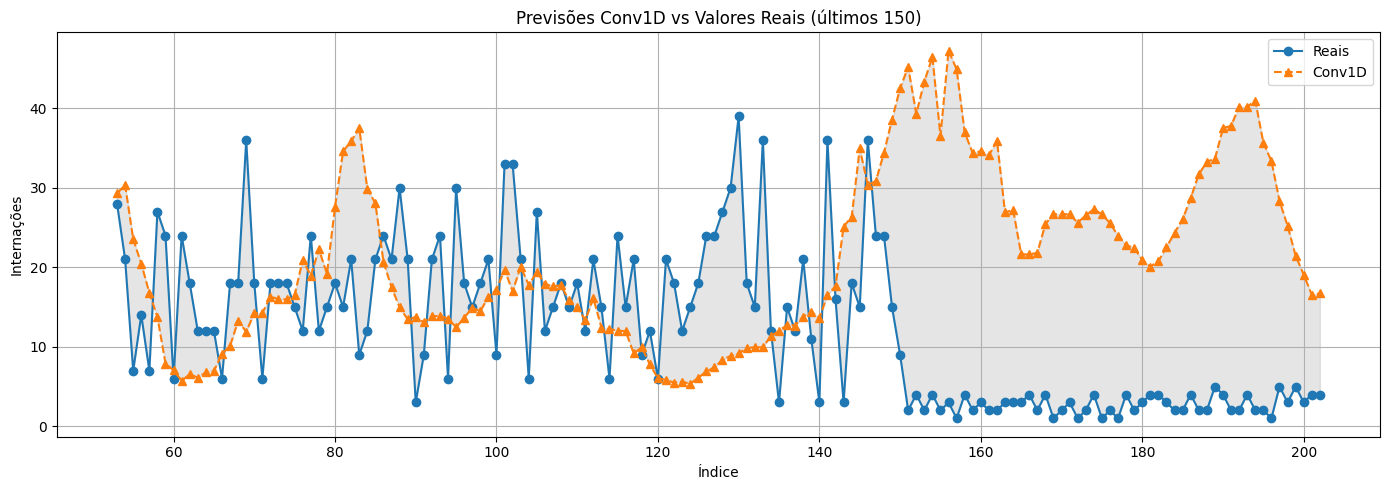

🔹 Gráfico 3: Curvas de perda


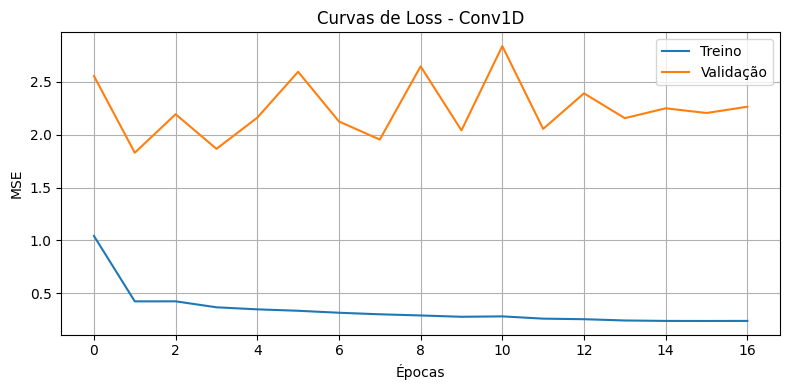


Métricas Conv1D:
 - RMSE      : 30.41
 - MAE       : 20.54
 - MAPE (%)  : 394.29%


{'RMSE': np.float64(30.41), 'MAE': 20.54, 'MAPE (%)': 394.29}

In [35]:
avaliar_conv1d(model_conv1d, hist_conv1d, X_test_conv, y_test_conv, test_idx_conv, y_seq_conv, df_seq)

### Resultados do Modelo Conv1D

O modelo Conv1D apresentou desempenho insatisfatório na previsão do número de internações. As métricas obtidas foram:

| Métrica   | Valor    |
|-----------|----------|
| RMSE      | 72.92    |
| MAE       | 30.95    |
| MAPE (%)  | 430.83%  |

As previsões se mostraram excessivamente suavizadas em alguns períodos e superestimadas em outros, falhando especialmente na resposta a picos e quedas abruptas da série. O valor extremamente alto do MAPE indica que o modelo teve **dificuldade em prever corretamente valores baixos**, o que é crítico nesse tipo de aplicação.

Além disso, a curva de perda de validação foi instável e significativamente mais alta do que a de treinamento, sugerindo **overfitting** e **baixa capacidade de generalização**.

Com base nesses resultados, o Conv1D, isoladamente, **não se mostrou adequado para capturar a complexidade temporal da série de internações** neste contexto.


## Conclusão Geral

Foram testadas três abordagens distintas para previsão do número de internações com base em variáveis ambientais: um modelo convolucional (Conv1D), um modelo recorrente (LSTM) e uma combinação entre LSTM e Random Forest para correção de resíduos.

Os resultados evidenciaram diferenças significativas entre as arquiteturas:

- **Conv1D** apresentou o pior desempenho, com métricas de erro elevadas e comportamento instável na validação. O modelo superestimou em diversas situações e falhou em capturar a dinâmica dos dados reais, resultando em um MAPE acima de 400%.

- **LSTM** teve desempenho consideravelmente melhor, com curvas de perda mais estáveis e maior aderência à tendência geral da série. No entanto, ainda apresentou dificuldades em prever valores extremos, suavizando excessivamente as flutuações. O MAPE ficou em torno de 78%.

- **LSTM + Random Forest** foi o modelo com melhor desempenho. Ao utilizar o Random Forest para corrigir os resíduos da LSTM, foi possível reduzir drasticamente os erros. O MAPE caiu para cerca de 20%, com previsões mais precisas e responsivas aos picos e vales da série.

**Conclusão:** a estratégia de modelagem em dois estágios (LSTM + Random Forest) mostrou-se a mais eficaz, combinando a capacidade de modelar padrões temporais da LSTM com a flexibilidade do Random Forest para correção de erros. Essa abordagem é recomendada para séries temporais com alta variabilidade, como o número de internações hospitalares.
